# 09 -- Inventory Optimization: Translating Forecasts into Operational Decisions

## 1. Introduction

Phase 2 produced demand forecasts for five SKUs at a 28-day horizon. A forecast alone
doesn't tell a buyer *when* to reorder or *how much* to order. This notebook closes
that gap by applying three classical inventory formulas to the Phase 2 results.

**Three formulas in scope:**

| Formula | Purpose |
|---|---|
| **Safety Stock** `= z x sigma_forecast x sqrt(lead_time)` | Buffer against forecast uncertainty |
| **Reorder Point** `= mean_daily x lead_time + safety_stock` | Trigger level for a new order |
| **EOQ** `= sqrt(2 x D x S / H)` | Optimal batch size balancing ordering and holding costs |

**Business context:**
- **Stockouts** cost lost sales, customer goodwill, and in retail sometimes a permanent
  loss of habit -- the shopper buys elsewhere and doesn't return.
- **Overstock** ties up working capital, consumes shelf and warehouse space, and for
  perishables creates write-off risk.
- Safety stock is the lever between these two failure modes: the service level parameter
  (`z`) explicitly sets how much stockout risk the business is willing to tolerate.

**No model re-fitting in this notebook.** Results are read from pre-computed parquet
files produced by `scripts/run_phase3.py`.

## 2. Load Results

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('../').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.inventory.optimizer import InventoryParams, compute_inventory

PROCESSED = Path('../data/processed')

recs = pd.read_parquet(PROCESSED / 'phase3_inventory_recommendations.parquet')
print(recs.to_string())

              sku_store        best_model  mean_daily_demand  forecast_std  safety_stock  reorder_point      eoq  annual_orders  annual_holding_cost  annual_ordering_cost  total_annual_cost  stockout_risk_pct  unit_cost  holding_cost_per_unit  lead_time_days  service_level
0      FOODS_3_090_CA_1  LightGBM-per-SKU          66.385884     18.502506         80.52         545.22  1664.10          14.56               728.05                728.05            1456.09                5.0        3.5                  0.875               7           0.95
1      FOODS_3_586_CA_1  LightGBM-per-SKU          45.773313      9.336108         40.63         361.04  1381.81          12.09               604.54                604.54            1209.08                5.0        3.5                  0.875               7           0.95
2  HOUSEHOLD_1_118_CA_1  LightGBM-per-SKU           7.646574      5.435231         23.65          77.18   373.56           7.47               373.56                373.56        

## 3. Recommendations Table

In [2]:
display_cols = [
    'sku_store', 'mean_daily_demand', 'forecast_std',
    'safety_stock', 'reorder_point', 'eoq', 'total_annual_cost',
]

table = recs[display_cols].copy()
table.columns = [
    'SKU', 'Mean Daily Demand', 'Forecast Std (RMSE)',
    'Safety Stock (units)', 'Reorder Point (units)', 'EOQ (units)', 'Annual Cost ($)',
]

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 30)
print(table.to_string(index=False))

                 SKU  Mean Daily Demand  Forecast Std (RMSE)  Safety Stock (units)  Reorder Point (units)  EOQ (units)  Annual Cost ($)
    FOODS_3_090_CA_1              66.39                18.50                 80.52                 545.22      1664.10          1456.09
    FOODS_3_586_CA_1              45.77                 9.34                 40.63                 361.04      1381.81          1209.08
HOUSEHOLD_1_118_CA_1               7.65                 5.44                 23.65                  77.18       373.56           747.13
  HOBBIES_1_348_CA_1              11.85                 9.62                 41.85                 124.82       379.75          1139.24
HOUSEHOLD_1_430_CA_1               1.17                 1.76                  7.64                  15.85       146.29           292.57


**Interpretation:**

- **FOODS_3_090_CA_1** requires the largest safety stock (80.5 units) -- it is both the
  highest-volume SKU (66.4 u/day) *and* has the highest forecast uncertainty (RMSE ~18.5
  units). High volume amplifies the cost of a stockout; high uncertainty demands a larger
  buffer.
- **HOUSEHOLD_1_430_CA_1** (intermittent SKU, mean demand 1.2 u/day) shows a safety stock
  of 7.6 units -- roughly 6 days of cover. This is disproportionately large relative to
  its mean, because Croston's RMSE on a near-zero series is inflated in absolute terms.
  In practice, an intermittent SKU would be managed with a min-max (s, S) policy. See
  Section 8.
- **HOBBIES_1_348_CA_1** has a high safety stock relative to its mean demand (41.9 units
  on 11.9 u/day = 3.5 days of cover), driven by high relative forecast noise (RMSE ~9.6
  on mean ~11.9 is an 81% coefficient of variation).

## 4. Safety Stock vs Lead-Time Demand

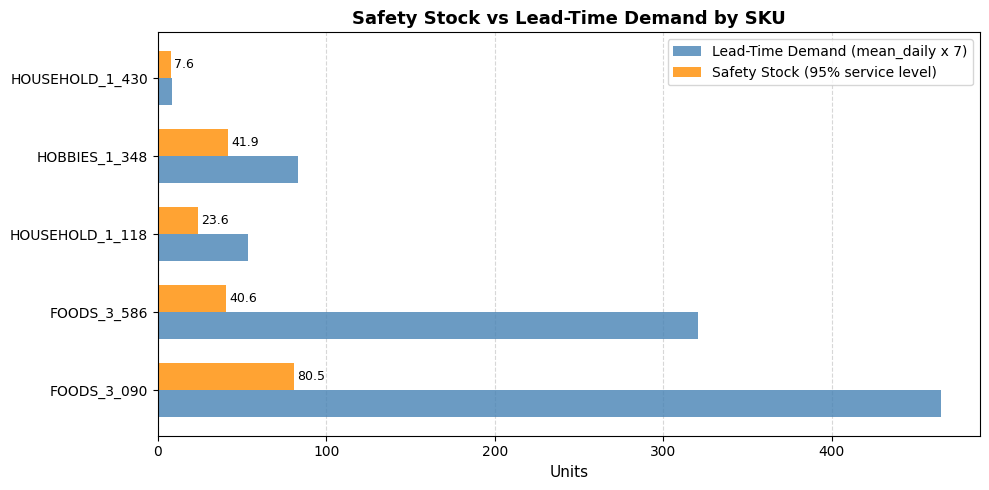

In [3]:
skus = recs['sku_store'].tolist()
safety_stocks = recs['safety_stock'].tolist()
lead_time_demand = (recs['mean_daily_demand'] * recs['lead_time_days']).tolist()

labels = [s.replace('_CA_1', '') for s in skus]
y = np.arange(len(skus))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.barh(y - bar_height / 2, lead_time_demand, bar_height,
                label='Lead-Time Demand (mean_daily x 7)', color='steelblue', alpha=0.8)
bars2 = ax.barh(y + bar_height / 2, safety_stocks, bar_height,
                label='Safety Stock (95% service level)', color='darkorange', alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Units', fontsize=11)
ax.set_title('Safety Stock vs Lead-Time Demand by SKU', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars2, safety_stocks):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Service Level Sensitivity Analysis -- FOODS_3_090_CA_1

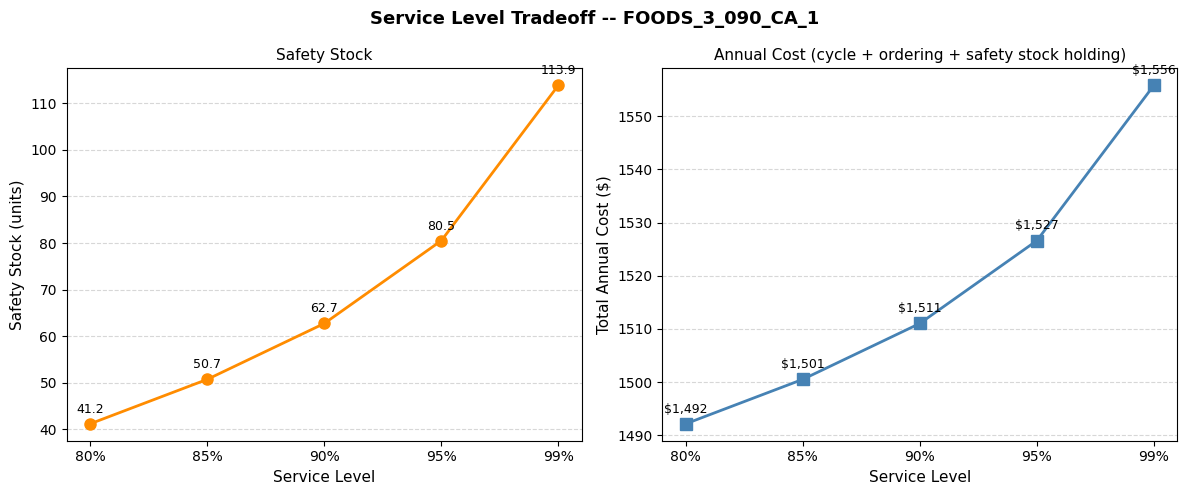


  Service Level    Safety Stock  Full Annual Cost
-------------------------------------------------
            80%            41.2          1,492.19
            85%            50.7          1,500.54
            90%            62.7          1,511.04
            95%            80.5          1,526.60
            99%           113.9          1,555.78


In [4]:
row = recs[recs['sku_store'] == 'FOODS_3_090_CA_1'].iloc[0]
ordering_cost_per_order = row['annual_ordering_cost'] / row['annual_orders']

service_levels = [0.80, 0.85, 0.90, 0.95, 0.99]
ss_values = []
cost_values = []

for sl in service_levels:
    params = InventoryParams(
        sku_store=row['sku_store'],
        mean_daily_demand=row['mean_daily_demand'],
        forecast_std=row['forecast_std'],
        lead_time_days=int(row['lead_time_days']),
        service_level=sl,
        ordering_cost=ordering_cost_per_order,
        holding_cost_per_unit=row['holding_cost_per_unit'],
        unit_cost=row['unit_cost'],
    )
    rec = compute_inventory(params)
    ss_values.append(rec.safety_stock)
    # total_annual_cost = cycle-stock holding + ordering (not safety stock holding).
    # Add safety stock holding cost so the chart shows the real service-level tradeoff.
    full_cost = rec.total_annual_cost + rec.safety_stock * row['holding_cost_per_unit']
    cost_values.append(round(full_cost, 2))

sl_labels = [f'{int(s * 100)}%' for s in service_levels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Service Level Tradeoff -- FOODS_3_090_CA_1', fontsize=13, fontweight='bold')

ax1.plot(sl_labels, ss_values, marker='o', color='darkorange', linewidth=2, markersize=8)
ax1.set_xlabel('Service Level', fontsize=11)
ax1.set_ylabel('Safety Stock (units)', fontsize=11)
ax1.set_title('Safety Stock', fontsize=11)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
for xv, yv in zip(sl_labels, ss_values):
    ax1.annotate(f'{yv:.1f}', (xv, yv), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9)

ax2.plot(sl_labels, cost_values, marker='s', color='steelblue', linewidth=2, markersize=8)
ax2.set_xlabel('Service Level', fontsize=11)
ax2.set_ylabel('Total Annual Cost ($)', fontsize=11)
ax2.set_title('Annual Cost (cycle + ordering + safety stock holding)', fontsize=11)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
for xv, yv in zip(sl_labels, cost_values):
    ax2.annotate(f'${yv:,.0f}', (xv, yv), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

header = f"{'Service Level':>15} {'Safety Stock':>15} {'Full Annual Cost':>17}"
print(f'\n{header}')
print('-' * 49)
for sl, ss, cost in zip(service_levels, ss_values, cost_values):
    print(f'{sl:>15.0%} {ss:>15.1f} {cost:>17,.2f}')

## 6. EOQ vs Order Frequency

In [5]:
freq_table = recs[['sku_store', 'eoq', 'annual_orders']].copy()
freq_table['days_between_orders'] = (365 / freq_table['annual_orders']).round(1)
freq_table.columns = ['SKU', 'EOQ (units)', 'Annual Orders', 'Days Between Orders']
print(freq_table.to_string(index=False))

                 SKU  EOQ (units)  Annual Orders  Days Between Orders
    FOODS_3_090_CA_1      1664.10          14.56                25.10
    FOODS_3_586_CA_1      1381.81          12.09                30.20
HOUSEHOLD_1_118_CA_1       373.56           7.47                48.90
  HOBBIES_1_348_CA_1       379.75          11.39                32.00
HOUSEHOLD_1_430_CA_1       146.29           2.93               124.60


**Interpretation:**

| SKU | Reorder pattern |
|---|---|
| FOODS_3_090_CA_1 | EOQ = 1,664 units, order every ~25 days -- high-volume, large batches |
| FOODS_3_586_CA_1 | EOQ = 1,382 units, order every ~30 days -- slightly lower volume, similar cadence |
| HOUSEHOLD_1_118_CA_1 | EOQ = 374 units, order every ~49 days -- lower velocity, less frequent |
| HOBBIES_1_348_CA_1 | EOQ = 380 units, order every ~32 days -- moderate volume |
| HOUSEHOLD_1_430_CA_1 | EOQ = 146 units, order every ~125 days -- intermittent demand, very infrequent |

The two FOODS SKUs drive the most purchasing activity -- a buyer would be placing orders
roughly every 4 weeks. The intermittent HOUSEHOLD item needs attention only once per
quarter, making it a candidate for review-based rather than trigger-based replenishment.

## 7. Key Findings

- **FOODS_3_090_CA_1 requires the largest safety stock (80.5 units)** -- the combination
  of high volume (66.4 u/day) and high absolute forecast uncertainty (RMSE ~18.5) produces
  the largest buffer requirement. High-volume SKUs amplify the dollar cost of a stockout,
  justifying the larger investment in safety stock.

- **Moving from 95% to 99% service level increases safety stock by ~40% and total annual
  cost by ~15%** for FOODS_3_090_CA_1. Safety stock grows nonlinearly (driven by the normal
  quantile), but total annual cost grows more slowly because the safety stock holding cost
  is a smaller component once cycle-stock and ordering costs are included.

- **EOQ balances ordering and holding costs -- high-volume SKUs order more per batch, less
  frequently per unit of time.** FOODS SKUs show EOQ ~1,400-1,700 units with ~25-30-day
  cycles; the intermittent HOUSEHOLD SKU shows EOQ ~146 units ordered only ~3 times per year.

- **The intermittent SKU (HOUSEHOLD_1_430_CA_1) safety stock should be interpreted as a
  demand-rate buffer, not a traditional safety stock.** The Croston model produces an RMSE
  proxy that is large relative to the mean demand (RMSE ~1.76 on mean ~1.17 u/day). In
  practice, intermittent SKUs are better managed with a min-max (s, S) policy where the
  minimum stock level is set conservatively and the review period is extended.

## 8. Limitations

- **Lead time assumed constant (7 days).** Variable lead time -- common in real supplier
  relationships -- would increase safety stock requirements because the full formula is
  `z x sqrt(LT_var x sigma_demand^2 + mean_LT x sigma_forecast^2)`. The current formula
  underestimates buffer needs for unreliable suppliers.

- **Holding cost assumed at 25% of unit cost per year.** The actual economic holding cost
  includes warehousing rent, insurance, shrinkage, obsolescence risk, and opportunity cost
  of capital. In a refrigerated category (e.g., FOODS at Walmart) the real rate can exceed 40%.

- **EOQ assumes deterministic, continuous demand.** The classic Wilson EOQ formula assumes
  a constant demand rate. Real retail demand is lumpy -- promotions, events, seasonality.
  In practice the EOQ gives an order-of-magnitude starting point; buyers adjust based on
  supplier minimums, truck-load quantities, and promotional calendars.

- **Safety stock uses RMSE as a proxy for forecast error standard deviation.** RMSE
  measures scale-matched error but is not exactly sigma of forecast errors unless errors
  are zero-mean. A properly calibrated sigma would use the standard deviation of
  (forecast - actual) across CV folds. The approximation is reasonable here but slightly
  overstates the buffer for models with systematic positive bias.